In [1]:
import lamination_station as lamstat
import os
import anndata
import scanpy as sc
import seaborn
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import networkx as nx
# import cuml
import pyro
import torch
if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

pyro.set_rng_seed(13)
torch.manual_seed(13)


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/lamination_station/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is not available


# Dataset

Should be a pandas table with an x column, y column and a classification

- Removing glia or cell types not expected to define your structures is highly recommended

- Orienting your sections isn't necessary

- BUT-Make sure your sections are not overlapping in your x,y space
  - You can just add a different arbitrary large number to x or y for each separate tissue section

In [2]:
x_col = 'center_x'
y_col = 'center_y'
taxon_level = 'WithinArea_cluster_Corr'

In [3]:
import h5py
with h5py.File('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/spatial_sections_analyzed.h5ad') as f:
    df = anndata.io.read_elem(f['obs'])
with h5py.File('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/spatial_sections_analyzed.h5ad') as f:
    df = anndata.io.read_elem(f['obs'])


In [4]:
cur_max = 0
for i in df['batch'].cat.categories:
    df.loc[df['batch']==i,'center_x_translated'] = df.loc[df['batch']==i,x_col] + cur_max
    cur_max += df.loc[df['batch']==i,x_col].max() + 100
        

In [5]:
x_col = 'center_x_translated'
y_col = 'center_y'

In [6]:
print(df)

                      center_x     center_y  center_z       volume  area  \
1338607175_1        860.854919   705.950073  0.956000   220.770025   NaN   
1338607175_2        882.725464   708.618286  1.825716  1477.700200   NaN   
1338607175_4        926.239502   709.224548  1.563492   298.932720   NaN   
1338607175_5       1047.950806   714.332397  1.869565   161.695738   NaN   
1338607175_6        950.633057   717.737244  1.789994  1080.001351   NaN   
...                        ...          ...       ...          ...   ...   
1338611863_132645  9019.798828  9049.273438  4.135484   253.401471   NaN   
1338611863_132646  9029.815430  9052.840820  2.524823   406.628390   NaN   
1338611863_132647  8998.589844  9058.143555  1.606557   104.768378   NaN   
1338611863_132648  8989.747070  9060.834961  1.666667   214.991696   NaN   
1338611863_132649  9031.466797  9066.241211  0.153846    30.752386   NaN   

                   polygon_center_x  polygon_center_y  polygon_center_z  \
1338607175_1

In [7]:
# df = df.loc[(df['Class_Corr'] != 'non-neuronal')]

In [8]:
print(df)

                      center_x     center_y  center_z       volume  area  \
1338607175_1        860.854919   705.950073  0.956000   220.770025   NaN   
1338607175_2        882.725464   708.618286  1.825716  1477.700200   NaN   
1338607175_4        926.239502   709.224548  1.563492   298.932720   NaN   
1338607175_5       1047.950806   714.332397  1.869565   161.695738   NaN   
1338607175_6        950.633057   717.737244  1.789994  1080.001351   NaN   
...                        ...          ...       ...          ...   ...   
1338611863_132645  9019.798828  9049.273438  4.135484   253.401471   NaN   
1338611863_132646  9029.815430  9052.840820  2.524823   406.628390   NaN   
1338611863_132647  8998.589844  9058.143555  1.606557   104.768378   NaN   
1338611863_132648  8989.747070  9060.834961  1.666667   214.991696   NaN   
1338611863_132649  9031.466797  9066.241211  0.153846    30.752386   NaN   

                   polygon_center_x  polygon_center_y  polygon_center_z  \
1338607175_1

In [9]:
# making my dataframe
# merged_adata = sc.read_h5ad('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/spatial_sections_analyzed.h5ad')


# df = merged_adata.obs
df.to_csv('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/merfish_coords_classes.tsv',sep='\t')

In [10]:
# commented to keep categoricals
# df = pd.read_csv('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/merfish_coords_classes.tsv',sep='\t',index_col=0)

In [11]:
df.loc[:,[x_col,y_col,taxon_level]] #This is what your starting data frame should look like

,center_x_translated,center_y,WithinArea_cluster_Corr
1338607175_1,860.854919,705.950073,L5 IT_7
1338607175_2,882.725464,708.618286,L6 CT_4
1338607175_4,926.239502,709.224548,Endo_1
1338607175_5,1047.950806,714.332397,VLMC_1
1338607175_6,950.633057,717.737244,L5 IT_1
...,...,...,...
1338611863_132645,39949.187500,9049.273438,Astro_3
1338611863_132646,39959.203125,9052.840820,Micro/PVM_1
1338611863_132647,39927.976562,9058.143555,Oligo_2
1338611863_132648,39919.132812,9060.834961,Astro_4


In [12]:

df_grads,cell_types,gradients,comp_vectors_pca,comp_vectors,neighbor_counts,neighbor_type_vecs = lamstat.pp.calculate_comp_grads(
    df,
    x_col,
    y_col,
    celltype_col=taxon_level,
    near_k=30,far_k=60,
    near_quantile=0.9,far_quantile=0.9, # Uncomment this block if you have QC gradients leading to differences in detected cell density
    use_cuda=True,grad_clip=0.9
)

/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/lamination_station/src/lamination_station/preprocessing.py:130: RuntimeWarning: divide by zero encountered in divide
  scales = np.where(norms>0, np.minimum(1.0, thresh/norms), 1.0)


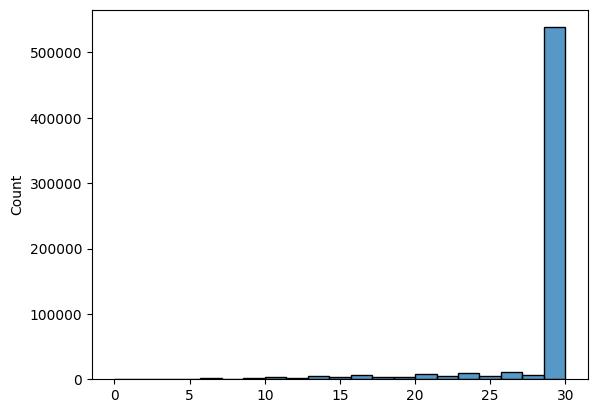

In [13]:
# #Uncomment this block if you have QC gradients leading to differences in detected cell density
seaborn.histplot(neighbor_counts.sum(1))
plt.show()
counts_over_thresh = neighbor_counts.sum(1)>20 #Keep cells with more than 10 neighbors within threshold
df_grads,cell_types,gradients,comp_vectors_pca,comp_vectors,neighbor_counts,neighbor_type_vecs = df_grads.loc[counts_over_thresh,:],cell_types[counts_over_thresh],gradients[counts_over_thresh],comp_vectors_pca[counts_over_thresh],comp_vectors[counts_over_thresh],neighbor_counts.loc[counts_over_thresh],neighbor_type_vecs.loc[counts_over_thresh]

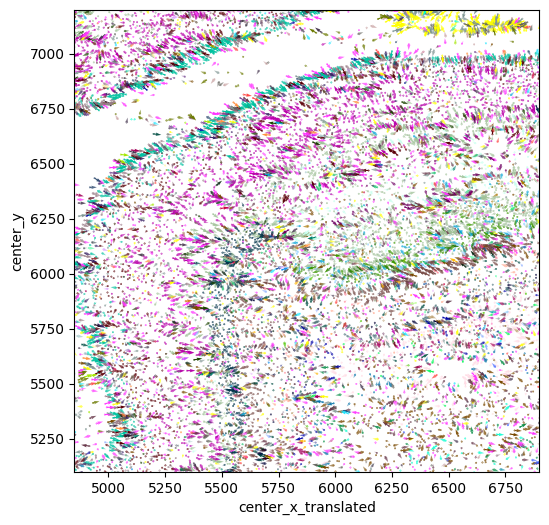

In [14]:
# Just plotting arrows
xlim = (4850,6900) # You'll need to pick your own coords
ylim = (5100,7200)
lamstat.pl.plot_gradient_arrows(df_grads,gradients,'WithinArea_cluster_Corr',x_col,y_col,xlim,ylim,scale=0.004)

Epoch:  67%|██████▋   | 100/150 [55:36<27:36, 33.14s/it] 

[Epoch 100] avg ELBO loss: 64108.71


Epoch: 100%|██████████| 150/150 [1:23:09<00:00, 33.26s/it]


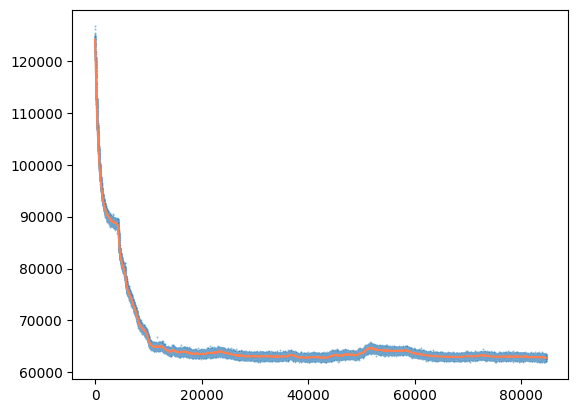

In [15]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

out,struct_logits,struct_comp,losses = lamstat.model.run_model(
    df_grads,
    cell_types,
    neighbor_counts,
    gradients,
    neighbor_type_vecs,
    LATENT_DIM = 2,
    NUM_STRUCTURES = 30, # might need to play with this, pick a number more than your expected structures
    num_epochs=150,
    lr_steps = [1e-3],
    batch_size = 1024,
    STRUCT_SCALE_SCALE = 1., # Penalize broadness structure definitions
    OBS_FAMILY = "poisson",
    STRUCT_LOC_PRIOR_SCALE = 5., #lower penalizes cluster redundancy more
    LOSS_SCALE = 1., #loss scalar multiplier (only use if loss is crazy big/small)
    HIDDEN_DIM = 512, #Encoder/decoder dim
    HIDDEN_DIM_CLASSIFIER = 128, # classifier dim
    device = device
)

lamstat.pl.plot_loss(losses)

G = lamstat.po.build_structure_graph(out)

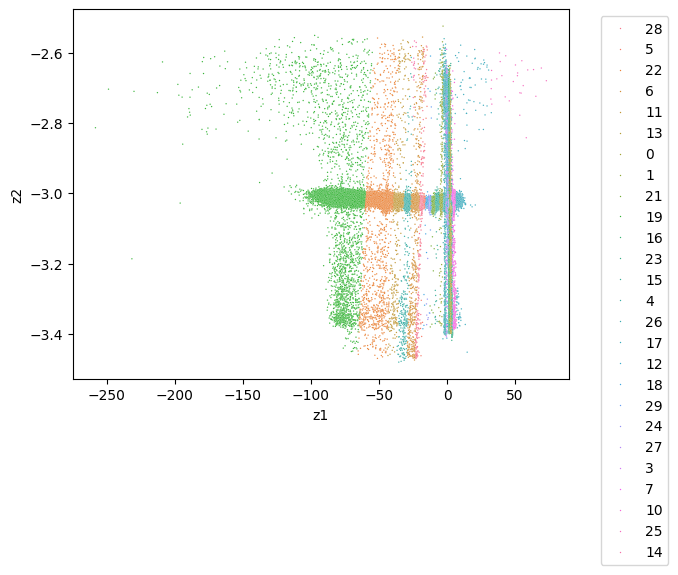

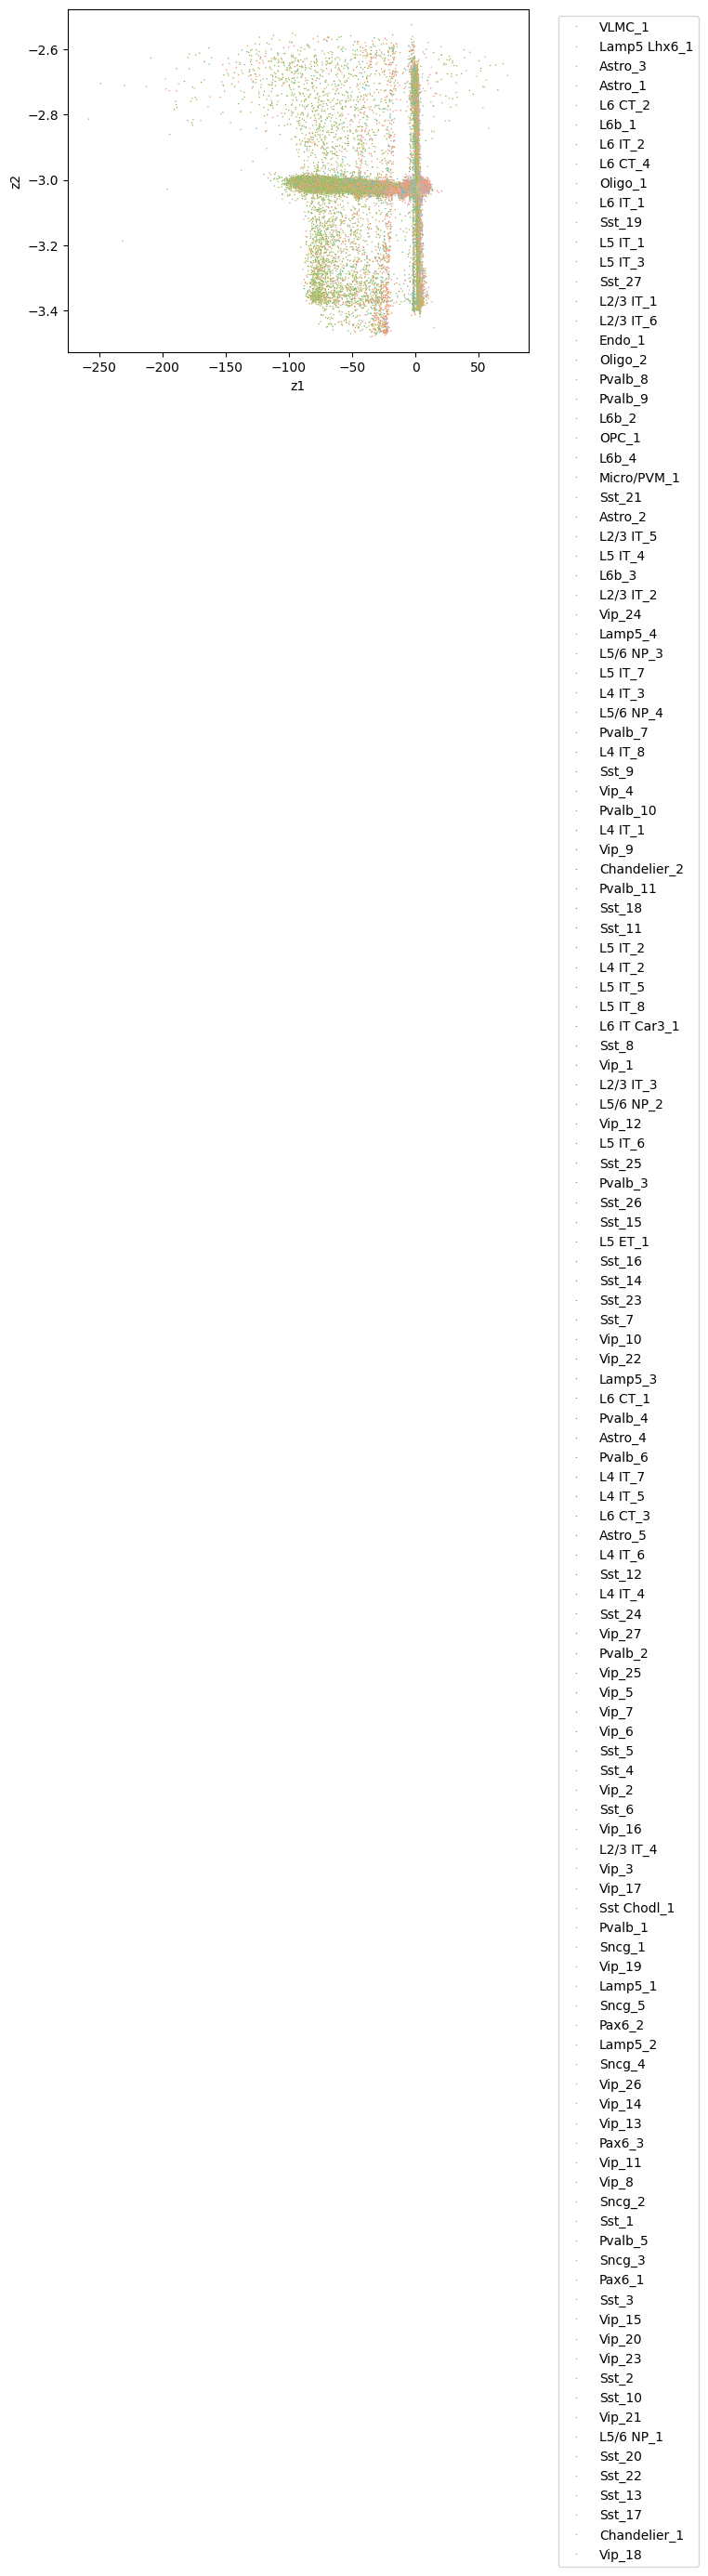

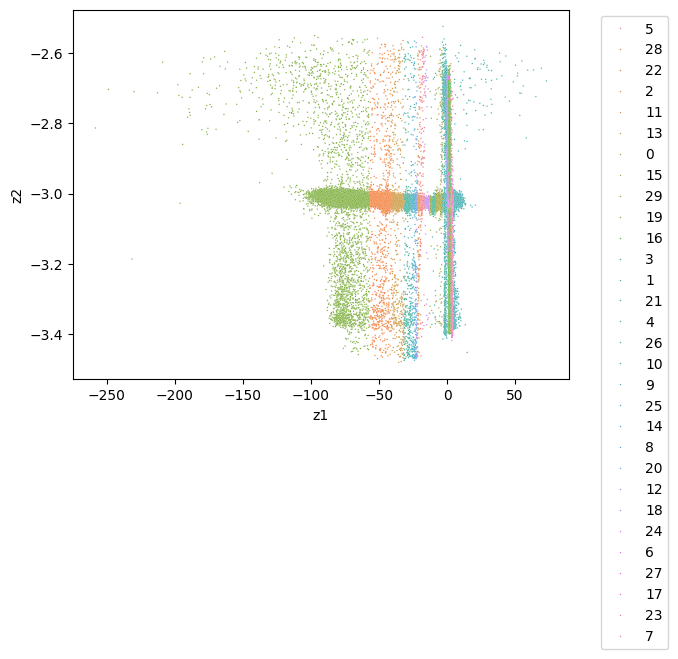

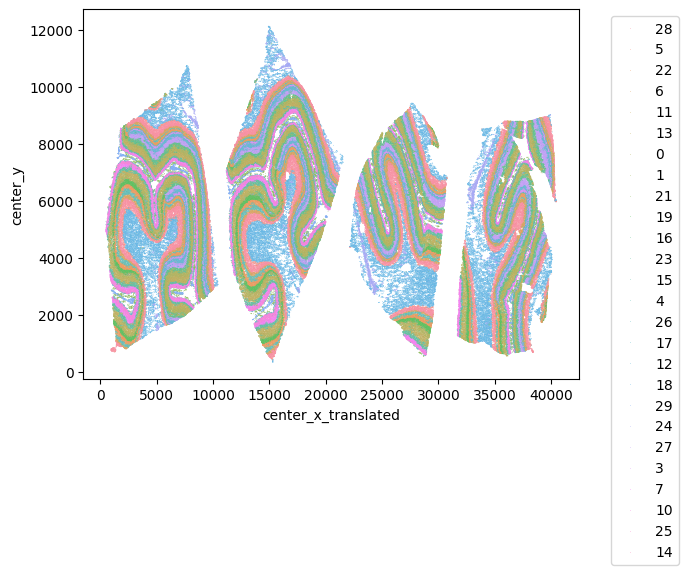

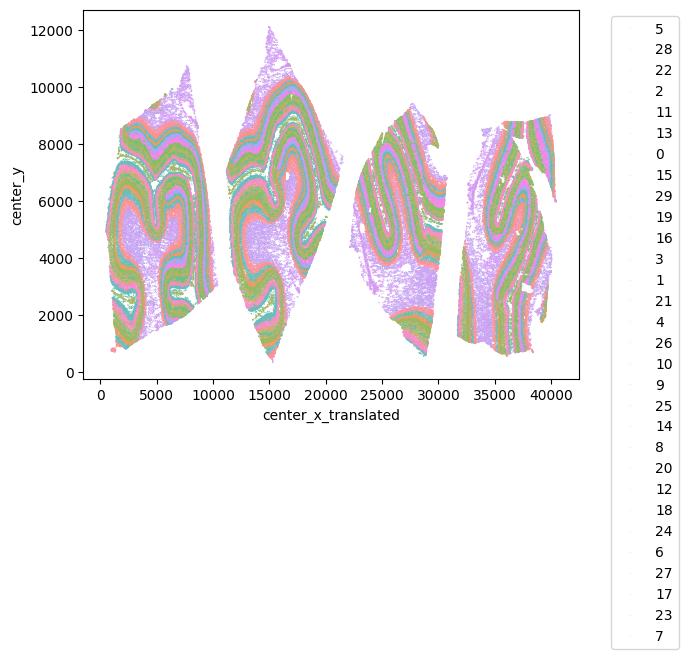

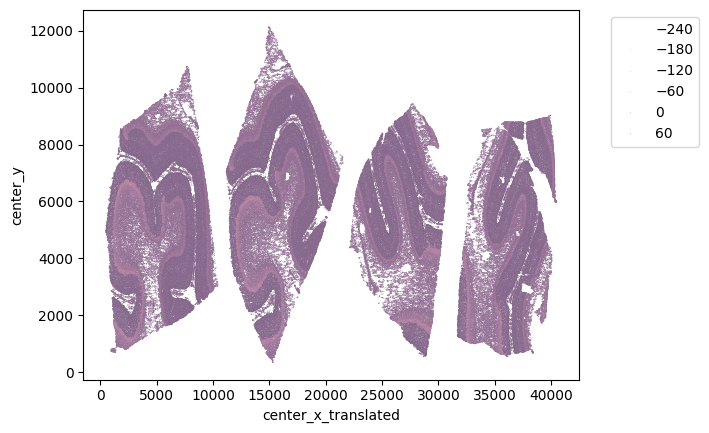

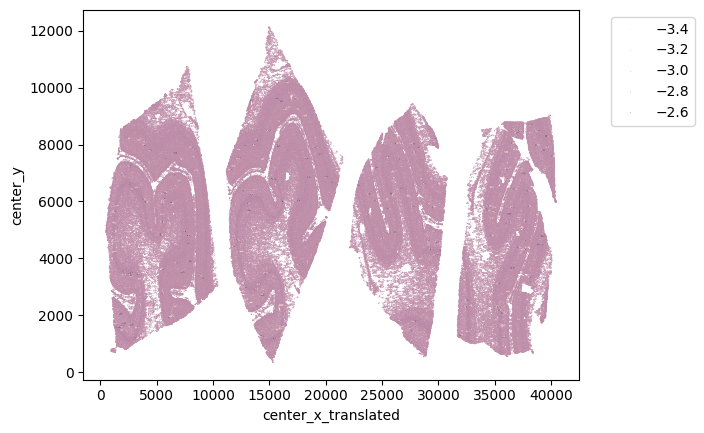

flat comp_df


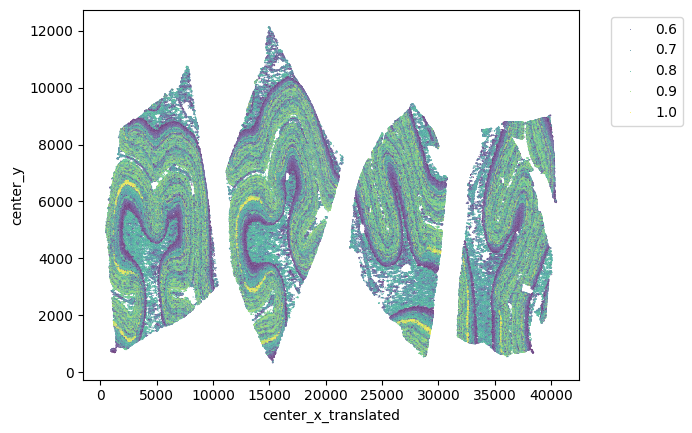

/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/lamination_station/src/lamination_station/plotting.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/lamination_station/src/lamination_station/plotting.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Axes: xlabel='x_graph', ylabel='y_graph'>,
 <Axes: xlabel='x_graph', ylabel='y_graph'>)

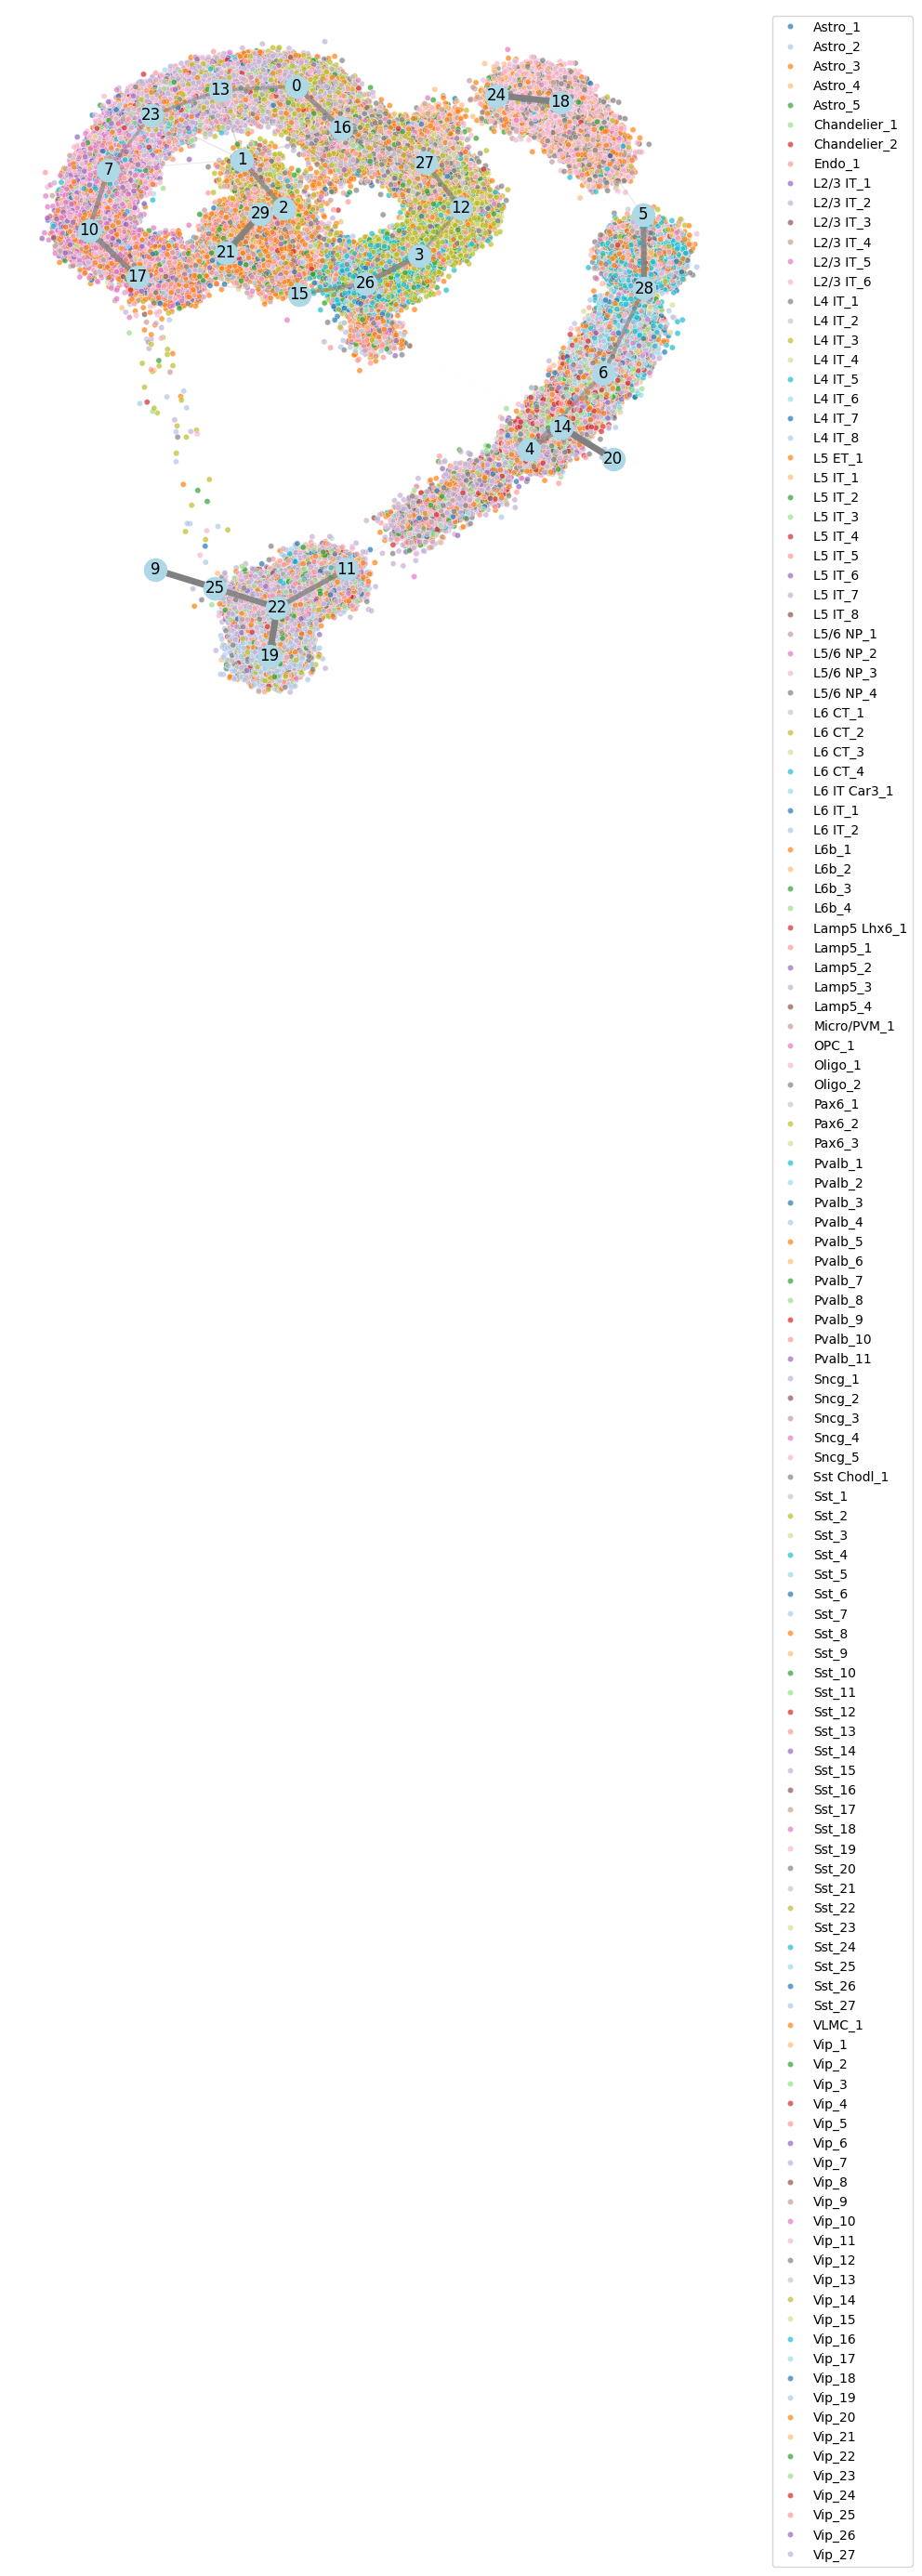

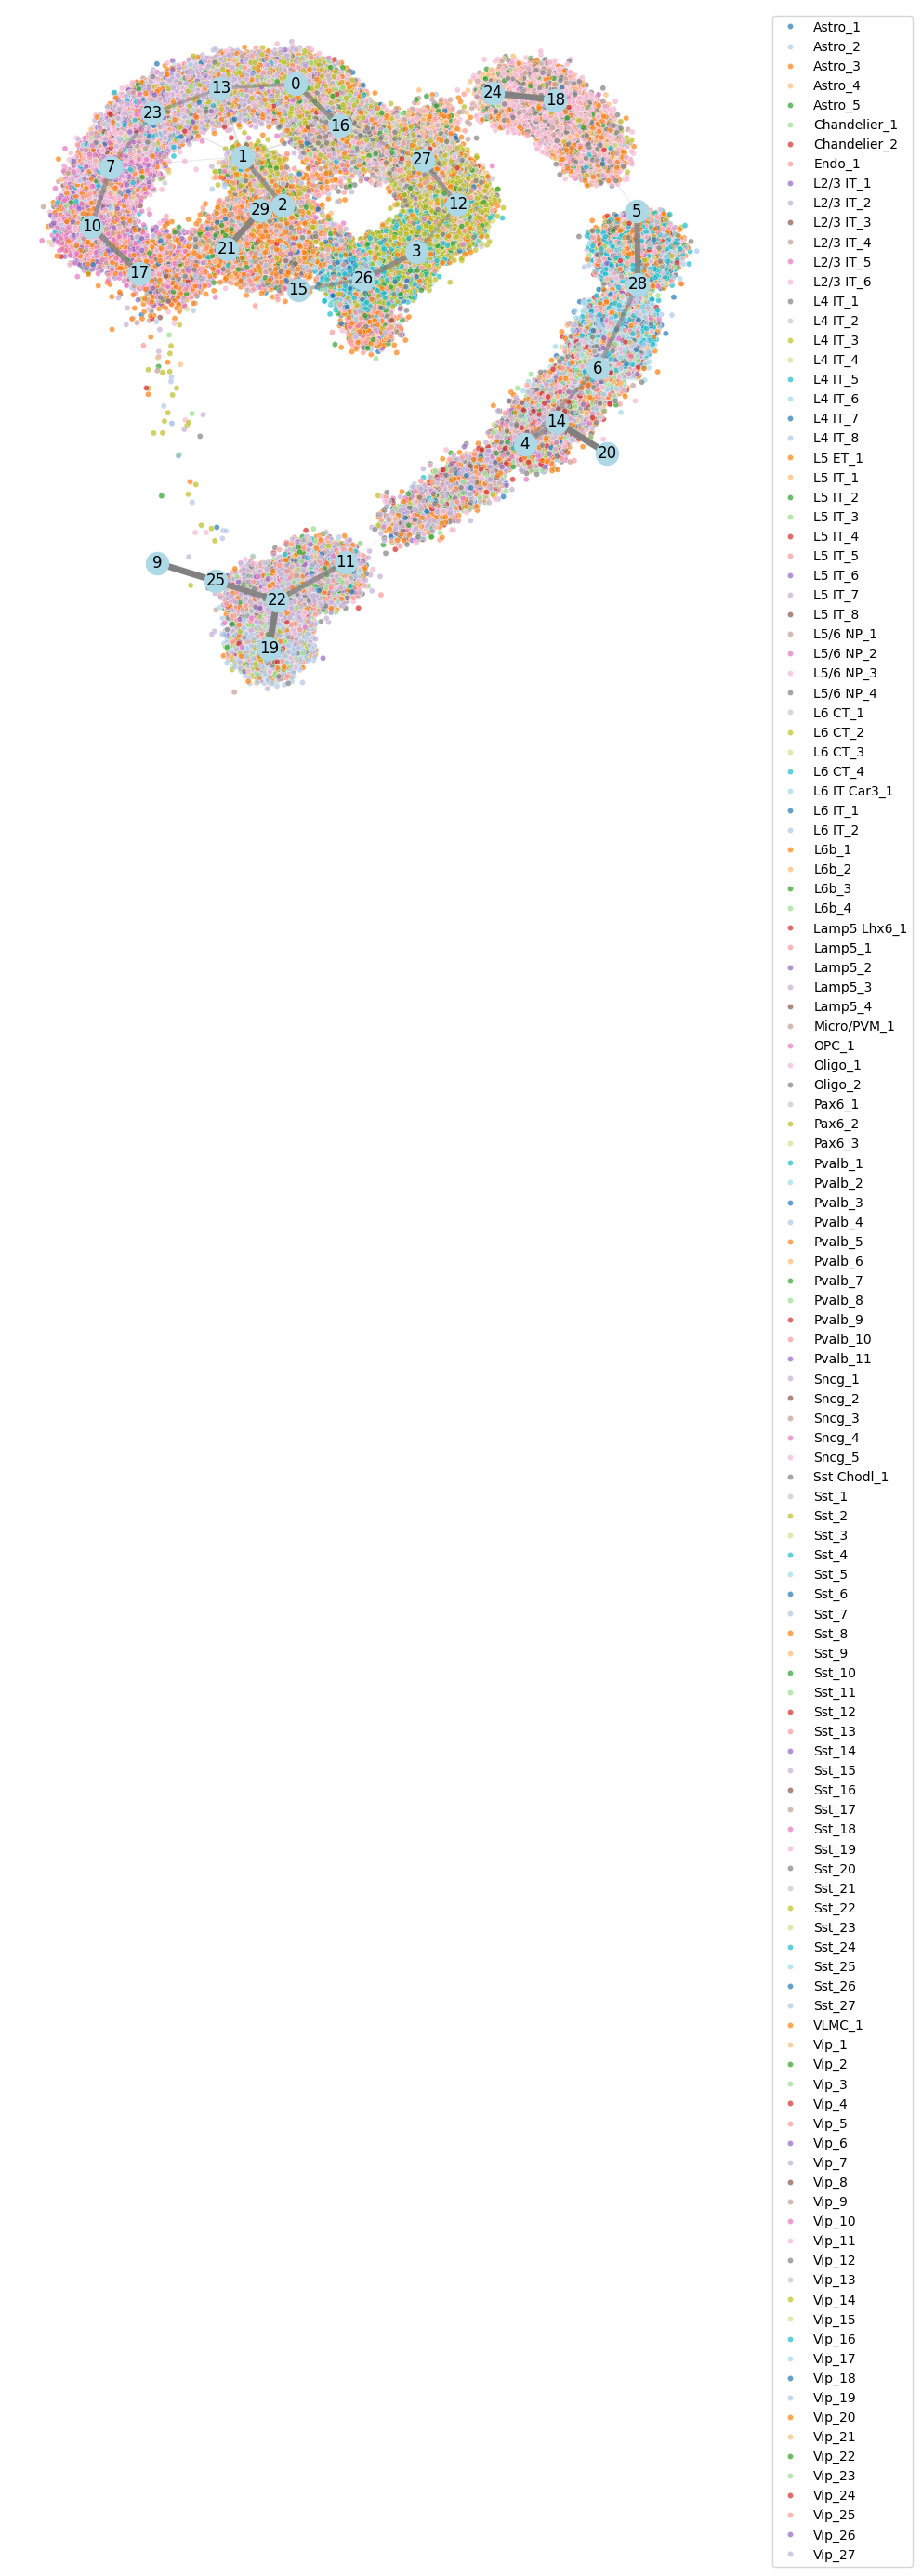

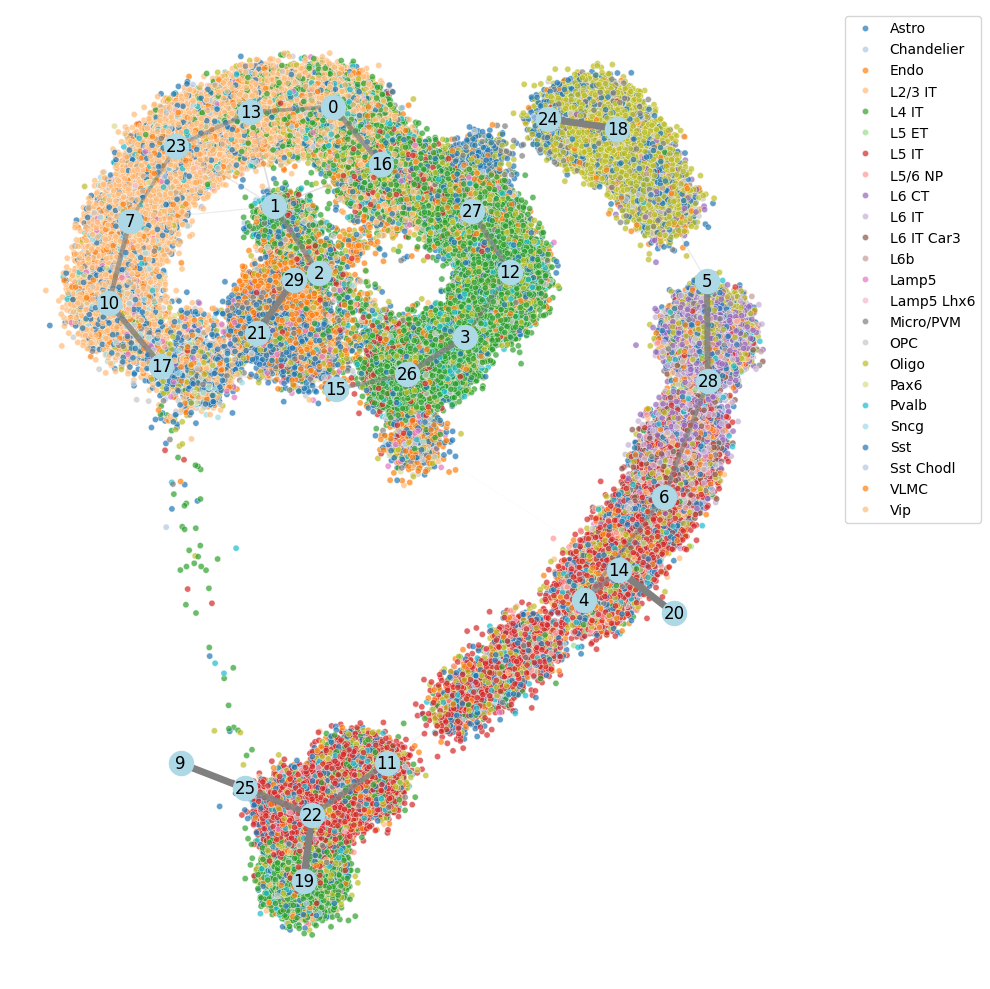

In [16]:

seaborn.scatterplot(x=out['z1'], y=out['z2'], hue=out['structure_pred1'].astype(str), s=1)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()
seaborn.scatterplot(x=out['z1'], y=out['z2'], hue=out[taxon_level].astype(str), s=1)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()
seaborn.scatterplot(x=out['z1'], y=out['z2'], hue=out['structure_pred_nearest'].astype(str), s=1)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

seaborn.scatterplot(x=out[x_col], y=out[y_col], hue=out['structure_pred1'].astype(str), s=0.2)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()
seaborn.scatterplot(x=out[x_col], y=out[y_col], hue=out['structure_pred_nearest'].astype(str), s=0.2)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()
seaborn.scatterplot(x=out[x_col], y=out[y_col], hue=out['z1'], s=0.2)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()
seaborn.scatterplot(x=out[x_col], y=out[y_col], hue=out['z2'], s=0.2)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

try:
    comp_df = pd.DataFrame(struct_comp,columns=df_grads[taxon_level].cat.categories.sort_values()).loc[merged_adata.obs['structure_pred'].cat.categories.astype(int)]
    seaborn.clustermap(comp_df/comp_df.sum(0))
    plt.show()
except:
    print('flat comp_df')

seaborn.scatterplot(
    x=out[x_col],
    y=out[y_col],
    hue=out["phi"],
    s=0.5,
    palette="viridis"
)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
# cb = plt.colorbar()
# cb.set_label("phi = p₁/(p₁+p₂)")
plt.show()

# ─────────────── 7) build & draw co-occurrence graph ───────────────
# build sets of samples where each struct appears in top2


lamstat.pl.plot_cells_on_structure_graph(
    out=out,
    G=G,
    jitter=0.03,      # e.g. 0.01–0.1
    cell_size=20,
    cell_alpha=0.7,
    color_col=taxon_level,
    figsize=(10,10),
    spring_k=0.2,     # tune for spacing
    seed=42
)
lamstat.pl.plot_cells_on_structure_graph(
    out=out,
    G=G,
    jitter=0.03,      # e.g. 0.01–0.1
    cell_size=20,
    cell_alpha=0.7,
    color_col='WithinArea_cluster_Corr',
    figsize=(10,10),
    spring_k=0.2,     # tune for spacing
    seed=42
)

lamstat.pl.plot_cells_on_structure_graph(
    out=out,
    G=G,
    jitter=0.03,      # e.g. 0.01–0.1
    cell_size=20,
    cell_alpha=0.7,
    color_col='WithinArea_subclass_Corr',
    figsize=(10,10),
    spring_k=0.2,     # tune for spacing
    seed=42
)


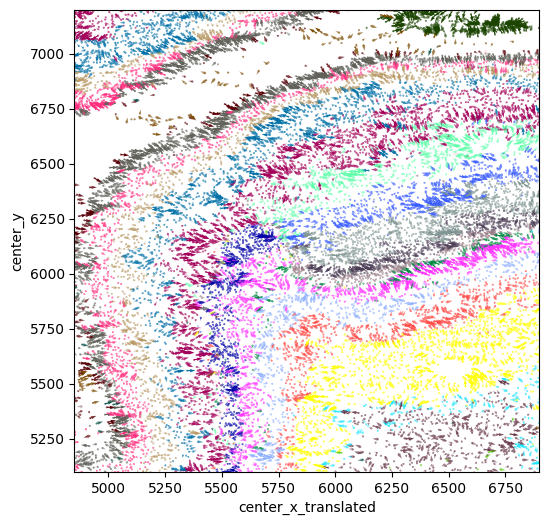

In [17]:
xlim = (4850,6900) # You'll need to pick your own coords
ylim = (5100,7200)
lamstat.pl.plot_gradient_arrows(out,gradients,'structure_pred1',x_col,y_col,xlim,ylim,scale=0.004)

# Assigning depth on graph

The walks can sometimes be finicky... worst case you might have to put the nodes into a manual order

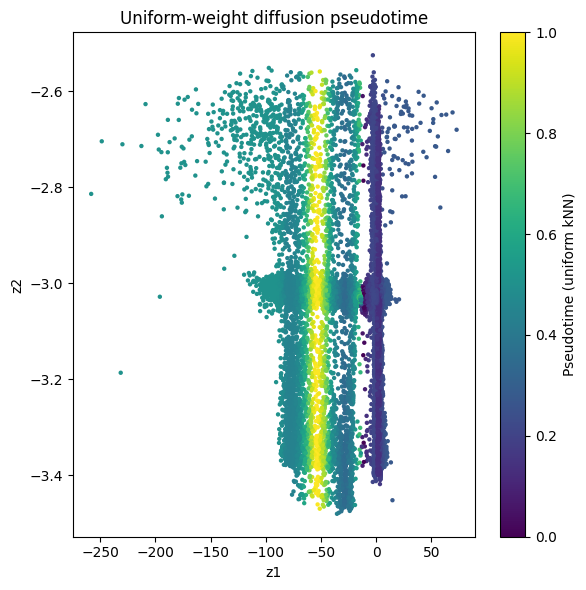

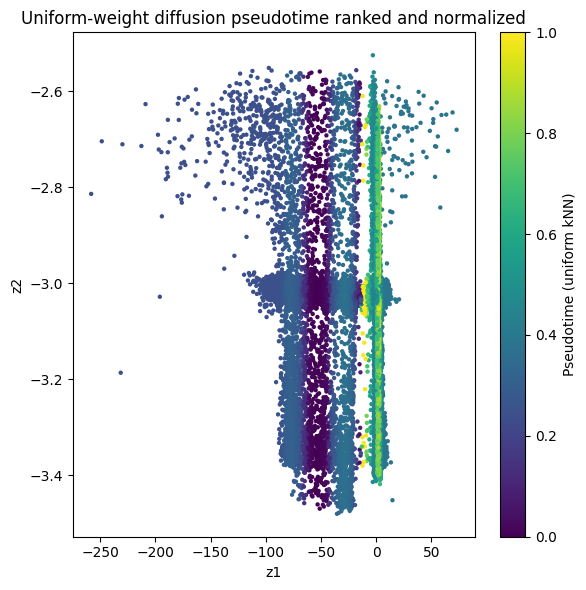

In [18]:
X = out[['z1','z2']].values.astype(np.float32)

diffusion_time, normalized_ranks = lamstat.po.compute_diffusion_time(X,use_cuda=True)
out['spectral_diffusion'] = diffusion_time
out['spectral_diffusion_rank_normalized'] = normalized_ranks


alpha_mean = out.loc[out['WithinArea_subclass_Corr'] == 'L6b',
                    'spectral_diffusion_rank_normalized'].mean()

if alpha_mean > 0.5:
    out['spectral_diffusion_rank_normalized'] = (
        1 - out['spectral_diffusion_rank_normalized']
    )

plt.figure(figsize=(6,6))
plt.scatter(out['z1'], out['z2'], c=out['spectral_diffusion'], s=10, cmap='viridis', lw=0)
plt.xlabel('z1'); plt.ylabel('z2')
plt.colorbar(label='Pseudotime (uniform kNN)')
plt.title('Uniform‐weight diffusion pseudotime')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(out['z1'], out['z2'], c=out['spectral_diffusion_rank_normalized'], s=10, cmap='viridis', lw=0)
plt.xlabel('z1'); plt.ylabel('z2')
plt.colorbar(label='Pseudotime (uniform kNN)')
plt.title('Uniform‐weight diffusion pseudotime ranked and normalized')
plt.tight_layout()
plt.show()




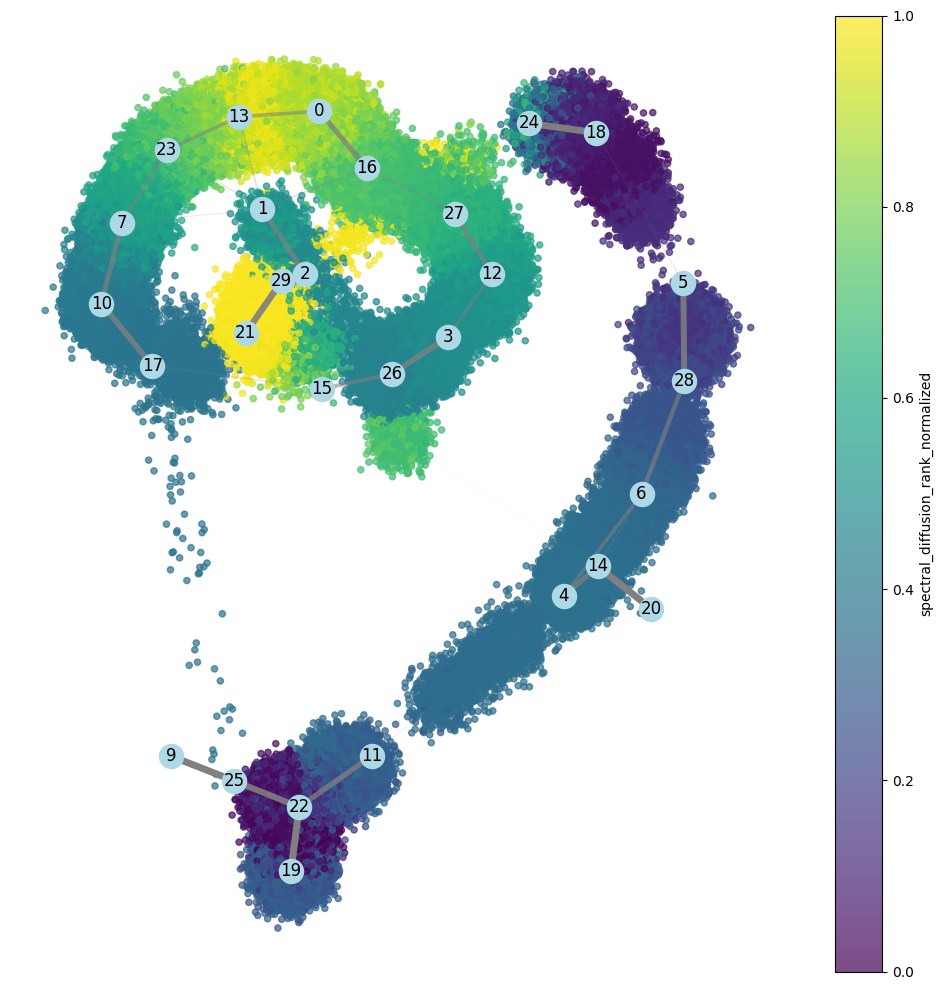

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/lamination_station/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


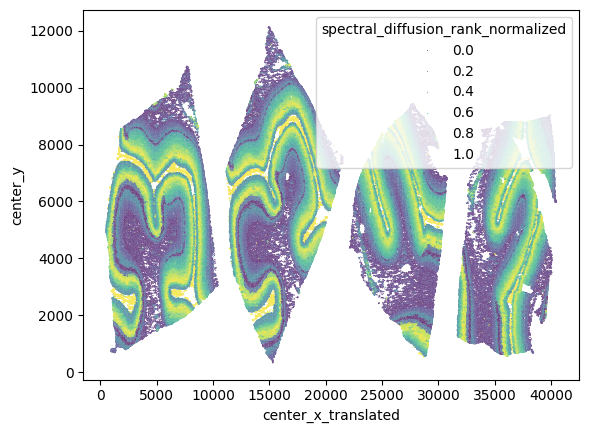

In [19]:
lamstat.pl.plot_cells_on_structure_graph(
    out=out,
    G=G,
    jitter=0.03,      # e.g. 0.01–0.1
    cell_size=20,
    cell_alpha=0.7,
    color_col='spectral_diffusion_rank_normalized',
    figsize=(10,10),
    spring_k=0.2,     # tune for spacing
    seed=42
)
plt.show()

seaborn.scatterplot(
    x=out[x_col],
    y=out[y_col],
    hue=out["spectral_diffusion_rank_normalized"],
    s=0.5,
    palette="viridis"
)
plt.show()

In [20]:
out = lamstat.po.compute_cell_diffusion(
    out, G,
    source_node=27,         # whichever structure‐node you want as source
    method='pagerank',     # or 'shortest_path'
    alpha=0.95
)

q99 = np.quantile(out['diffusion'],0.99)
q01 = np.quantile(out['diffusion'],0.01)
out['diffusion_normalized'] = np.clip(out['diffusion'],q01,q99)
out['diffusion_normalized'] = (out['diffusion_normalized'] -out['diffusion_normalized'].min()) / (out['diffusion_normalized'].max()-out['diffusion_normalized'].min())

{0: np.float64(0.6966747902318541), 1: np.float64(0.7130305152932751), 2: np.float64(0.5267307640929813), 3: np.float64(0.7953503377250167), 4: np.float64(0.202365766046324), 5: np.float64(0.15649155327341702), 6: np.float64(0.19549215846176277), 7: np.float64(0.5444335349926961), 8: np.float64(0.0), 9: np.float64(0.10198826303069647), 10: np.float64(0.5495858566780375), 11: np.float64(0.11275321844620816), 12: np.float64(0.9249720719152155), 13: np.float64(0.6253249186455943), 14: np.float64(0.27596453648779856), 15: np.float64(0.576937510375148), 16: np.float64(0.7961076952370412), 17: np.float64(0.4589556562056873), 18: np.float64(0.18765894310204387), 19: np.float64(0.10074253767827519), 20: np.float64(0.19037436168976102), 21: np.float64(0.3387802040119901), 22: np.float64(0.16787434533116963), 23: np.float64(0.5534039577544582), 24: np.float64(0.1879410125914775), 25: np.float64(0.14752577275094178), 26: np.float64(0.7209891198883349), 27: np.float64(1.0), 28: np.float64(0.189703

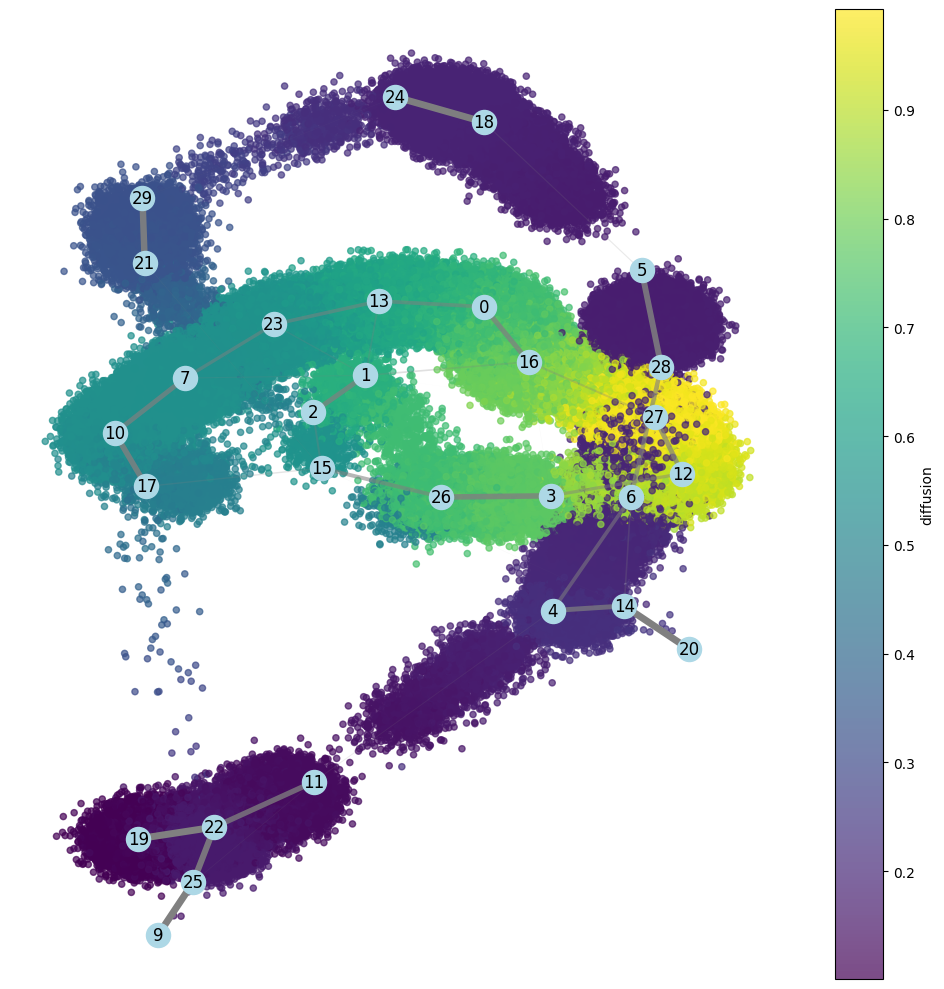

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/lamination_station/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


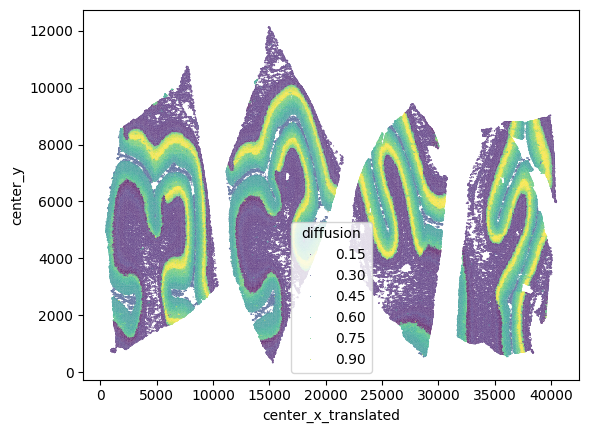

In [21]:
lamstat.pl.plot_cells_on_structure_graph(
    out=out,
    G=G,
    jitter=0.03,      # e.g. 0.01–0.1
    cell_size=20,
    cell_alpha=0.7,
    color_col='diffusion',
    figsize=(10,10),
    spring_k=0.1,     # tune for spacing
    seed=42
)
plt.show()

seaborn.scatterplot(
    x=out[x_col],
    y=out[y_col],
    hue=out["diffusion"],
    s=0.5,
    palette="viridis"
)
plt.show()

<Axes: xlabel='spectral_diffusion', ylabel='Count'>

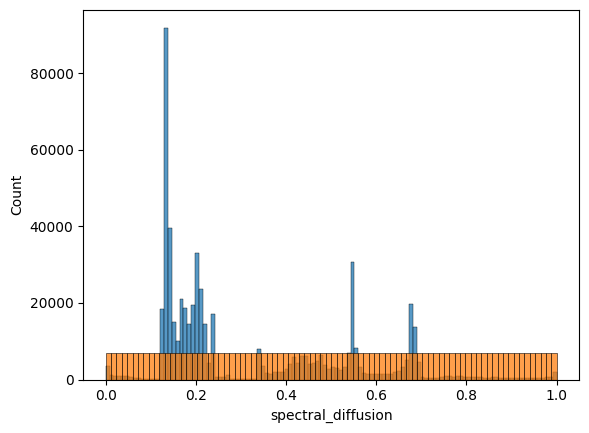

In [22]:
seaborn.histplot(out['spectral_diffusion'])
seaborn.histplot(out['spectral_diffusion_rank_normalized'])

In [23]:
# # Example ridgeplot code, you'll need to modify significantly and make your own color dict
# # color_dict = dict(zip(out['WithinArea_cluster_Corr'].cat.categories,merged_adata.uns['WithinArea_cluster_Corr_colors']))
# seaborn.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
# groups = out['WithinArea_cluster_Corr'].unique()
# pal = seaborn.cubehelix_palette(len(groups), rot=-.25, light=.7)
# unique_groups = out['WithinArea_cluster_Corr'].cat.categories.tolist()
# # if you want the rows in the same order as your dict:
# row_order = [g for g in color_dict.keys() if g in unique_groups]

# # build a palette mapping just those groups
# palette = pal#{ g: color_dict[g] for g in row_order }



# g = seaborn.FacetGrid(
#     out,
#     row="WithinArea_cluster_Corr",
#     hue="WithinArea_cluster_Corr",
#     aspect=15,
#     height=0.5,
#     palette=palette
# )

# g.map(
#     seaborn.kdeplot,
#     "spectral_diffusion_rank_normalized",
#     bw_adjust=0.5,
#     clip_on=False,
#     fill=True,
#     alpha=1,
#     linewidth=1.5
# )
# g.map(
#     seaborn.kdeplot,
#     "spectral_diffusion_rank_normalized",
#     clip_on=False,
#     color="w",
#     lw=2,
#     bw_adjust=0.5
# )
# g.refline(
#     y=0,
#     linewidth=2,
#     linestyle="-",
#     color=None,
#     clip_on=False
# )

# def label(x, color, label):
#     ax = plt.gca()
#     ax.text(
#         0,
#         0.2,
#         label,
#         fontweight="bold",
#         color=color,
#         ha="left",
#         va="center",
#         transform=ax.transAxes
#     )

# g.map(label, "diffusion")

# # overlap the plots
# g.figure.subplots_adjust(hspace=-0.25)

# # clean up
# g.set_titles("")
# g.set(yticks=[], ylabel="")
# g.despine(bottom=True, left=True)
# plt.xlim((-.45,1.))
# plt.show()



In [24]:
out.to_csv('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/lamstat_out_20250731.csv',sep='\t')
comp_df.to_csv('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/lamstat_struct_comp_20250731.csv',sep='\t')
pd.DataFrame(struct_logits).to_csv('/home/matthew.schmitz/Matthew/data/cortex_data/callaway_macaque/lamstat_struct_logits_20250731.csv',sep='\t')

NameError: name 'comp_df' is not defined